In [1]:
import pandas as pd

In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns

In [7]:
import yfinance as yf

In [9]:
from statsmodels.tsa.arima.model import ARIMA

In [10]:
from sklearn.metrics import mean_squared_error

In [11]:
import numpy as np

In [12]:
data = yf.download('TCS.NS', start='2020-01-01', end='2024-12-31')

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [13]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2020-01-01,1983.747925,1998.665208,1971.301364,1984.113908,1354908
2020-01-02,1974.641235,1995.049827,1966.907997,1995.049827,2380752
2020-01-03,2013.994019,2034.448414,1980.452707,1980.452707,4655761
2020-01-06,2013.811279,2037.148410,2002.325706,2017.975400,3023209
2020-01-07,2018.754272,2026.807695,1998.574465,2013.857959,2429317


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1237 entries, 2020-01-01 to 2024-12-30
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, TCS.NS)   1237 non-null   float64
 1   (High, TCS.NS)    1237 non-null   float64
 2   (Low, TCS.NS)     1237 non-null   float64
 3   (Open, TCS.NS)    1237 non-null   float64
 4   (Volume, TCS.NS)  1237 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.0 KB


In [15]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
count,1237.000000,1237.000000,1237.000000,1237.000000,1.237000e+03
mean,3143.880487,3174.764362,3114.205315,3144.636401,2.691733e+06
std,658.548564,660.819454,655.853004,658.237904,1.672450e+06
min,1511.924927,1557.291430,1381.439280,1441.103230,1.548950e+05
25%,2906.313965,2935.615676,2872.625668,2902.062138,1.663419e+06
50%,3195.053223,3220.442885,3163.307941,3191.703240,2.236866e+06
75%,3553.214355,3584.411402,3518.371582,3545.167379,3.173682e+06
max,4471.390137,4509.193819,4430.395122,4493.237606,1.983933e+07


In [16]:
data.isnull().sum()

,,0
Price,Ticker,
Close,TCS.NS,0
High,TCS.NS,0
Low,TCS.NS,0
Open,TCS.NS,0
Volume,TCS.NS,0


<Axes: title={'center': 'TCS STOCK CLOSING PRICING'}, xlabel='Date', ylabel='price (INR)'>

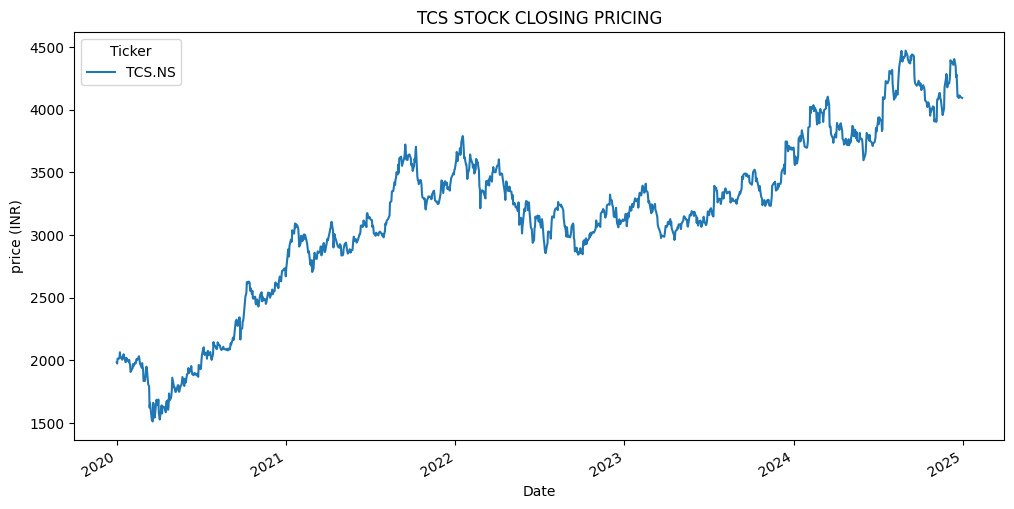

In [18]:
data['Close'].plot(figsize=(12, 6), title='TCS STOCK CLOSING PRICING', ylabel='price (INR)')

In [21]:
data['MA20'] = data['Close'].rolling(window=20).mean()

In [28]:
data['MA50'] = data['Close'].rolling(window=50).mean()

<Axes: title={'center': 'TCS Close Price with Moving Averages'}, xlabel='Date'>

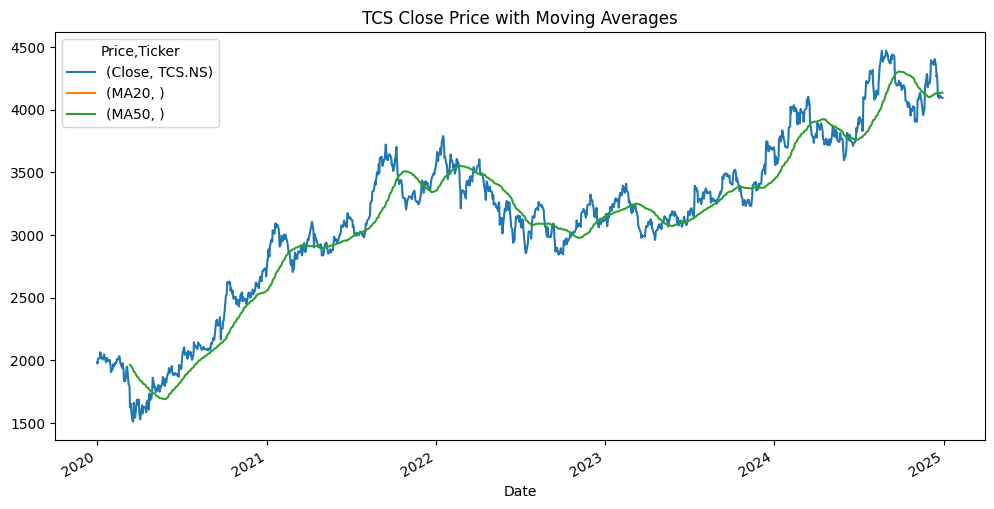

In [30]:
data[['Close', 'MA20', 'MA50']].plot(figsize=(12, 6), title='TCS Close Price with Moving Averages')

In [31]:
ts = data['Close'].fillna(method='ffill')

<ipython-input-31-07b0a1f74ca8>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts = data['Close'].fillna(method='ffill')


In [32]:
train = ts[:int(0.8 * len(ts))]
test = ts[int(0.8 * len(ts)):]

In [33]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train, order=(5, 1, 0))
model_fit = model.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [34]:
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


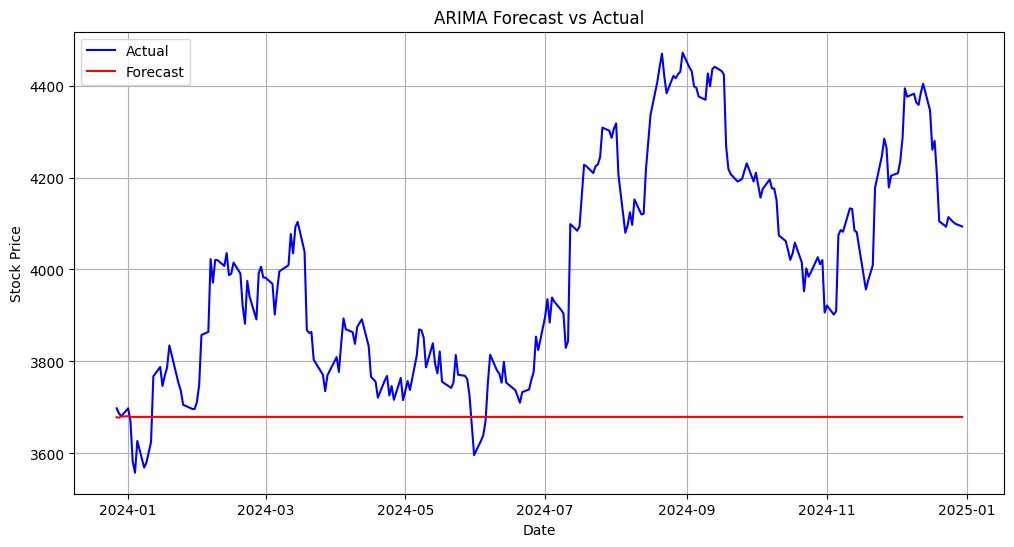

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Actual', color='blue')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

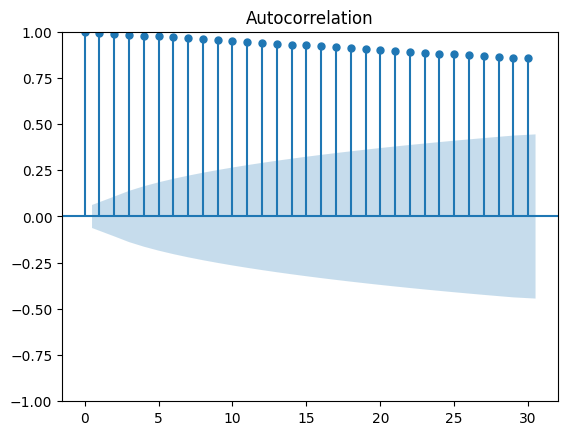

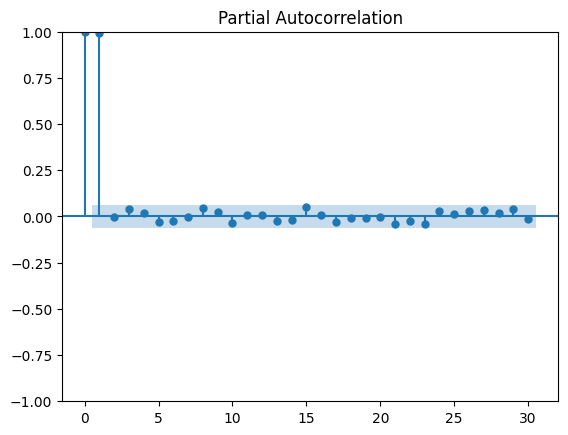

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(train)
plot_pacf(train)
plt.show()

In [37]:
model = ARIMA(train, order=(3, 1, 2))
model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [38]:
model = ARIMA(train, order=(3, 1, 2), trend='t')

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


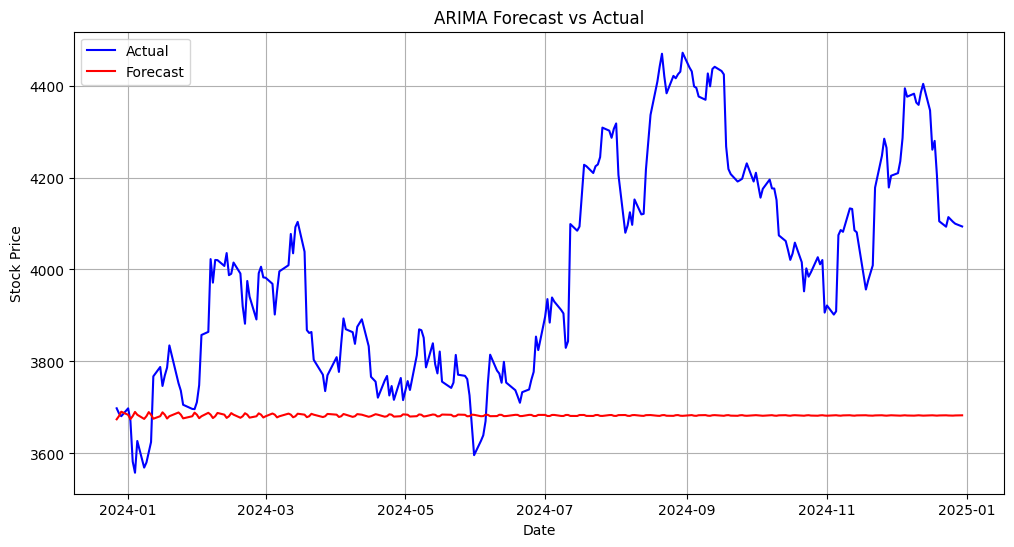

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Actual', color='blue')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 396.72277004396824
